#제16회 PHM 리더 양성을 위한 전문 기술 강좌
제조 설비 데이터 기반 품질 모니터링 실습

실습 데이터 준비


In [ ]:
from pathlib import Path
import urllib.request

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/jwsong0620/260818/main/content/data"
DATA_FILES = ["10AWG.csv", "24AWG.csv", "20230420.csv", "20230426.csv"]

for filename in DATA_FILES:
    path = DATA_DIR / filename
    if not path.exists():
        urllib.request.urlretrieve(f"{BASE_URL}/{filename}", path)

print("✓ 실습 데이터 준비 완료")

✓ 실습 데이터 준비 완료


# 0. Data Review

10AWG, 24AWG CSV 파일을 읽고 데이터 요약과 전체 CFM 파형을 확인함

## 0-1. 데이터 읽기

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 데이터 경로
DATA_DIR = Path("/content/data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 본 코드에 사용할 CSV 파일
csv_files = ["10AWG.csv", "24AWG.csv"]

# CSV를 읽어서 저장함
datasets = {}
force_datasets = {}
for file_name in csv_files:
    csv_path = DATA_DIR / file_name
    name = csv_path.stem
    df = pd.read_csv(csv_path)
    force_df = df[force_cols].apply(pd.to_numeric, errors="coerce")

    datasets[name] = df
    force_datasets[name] = force_df

    print(f"{name}: {df.shape}")

10AWG: (199, 201)
24AWG: (199, 201)


## 0-2. 데이터 요약

In [ ]:
# 데이터 샘플
for name, df in datasets.items():
    print(f"[{name}] 데이터 샘플")
    display(df.head())

# 파일별 통계
summary_rows = []

for name, df in datasets.items():
    force_df = force_datasets[name]
    label_count = df["Results"].value_counts().to_dict()

    summary_rows.append({
        "파일명": name,
        "샘플 수": len(df),
        "측정 포인트 수": len(force_cols),
        "최소값": force_df.min().min(),
        "최대값": force_df.max().max(),
        "평균값": force_df.to_numpy().mean(),
        "표준편차": force_df.to_numpy().std(),
        "g 개수": label_count.get("g", 0),
        "b 개수": label_count.get("b", 0),
        "f 개수": label_count.get("f", 0),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

[10AWG] 데이터 샘플


,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,...,data192,data193,data194,data195,data196,data197,data198,data199,data200,Results
0,9,13,15,20,27,33,66,100,130,164,...,0,0,0,0,0,0,0,0,0,g
1,56,51,82,88,104,106,123,128,150,180,...,0,0,0,0,0,0,0,0,0,g
2,36,36,46,58,64,76,89,97,105,123,...,0,0,0,0,0,0,0,0,0,g
3,63,64,67,80,76,86,94,105,117,137,...,0,0,0,0,0,0,0,0,0,g
4,35,29,32,38,49,50,57,72,100,124,...,0,0,0,0,0,0,0,0,0,g


[24AWG] 데이터 샘플


,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,...,data192,data193,data194,data195,data196,data197,data198,data199,data200,Results
0,13,21,35,56,93,110,148,187,239,274,...,0,0,0,0,0,0,20,7,15,g
1,33,52,53,69,87,105,128,165,198,257,...,0,0,0,0,0,0,0,0,8,g
2,36,55,65,92,130,148,168,214,254,292,...,0,0,0,0,2,3,6,2,16,g
3,0,0,7,19,35,52,77,124,161,197,...,14,14,11,15,8,3,0,0,0,g
4,0,23,26,45,66,91,116,170,214,258,...,0,0,0,0,0,0,0,0,0,g


,파일명,샘플 수,측정 포인트 수,최소값,최대값,평균값,표준편차,g 개수,b 개수,f 개수
0,10AWG,199,200,0,39566,17743.414573,14367.313694,176,14,9
1,24AWG,199,200,0,28535,8789.229095,8651.174162,156,24,19


### 0-3. 전체 CFM 파형 Plot

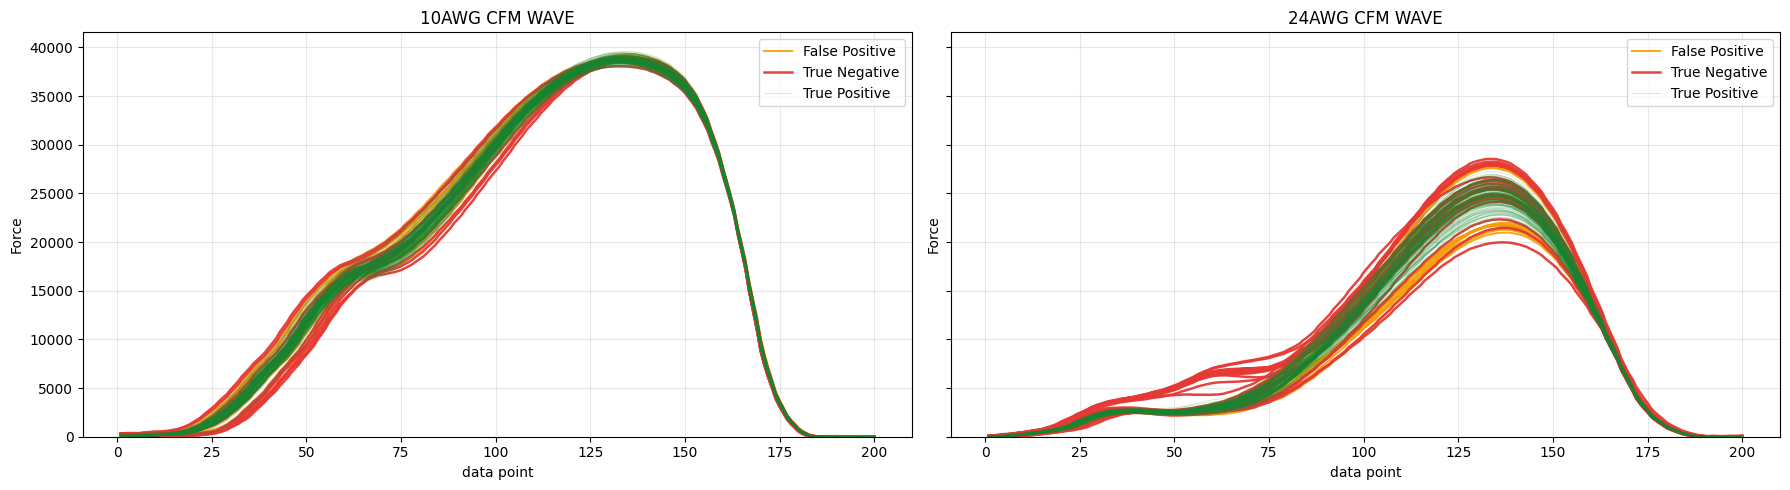

In [ ]:
# 10AWG, 24AWG 전체 샘플 파형
y_max = max(force_df.max().max() for force_df in force_datasets.values())

fig, axes = plt.subplots(1, len(datasets), figsize=(9 * len(datasets), 5), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, datasets.items()):
    force_df = force_datasets[name]


    # False Positive
    f_index = df[df["Results"] == "f"].index
    for i, idx in enumerate(f_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#f59e0b",
            alpha=0.9,
            linewidth=1.5,
            label="False Positive" if i == 0 else None,
        )

    # True Negative
    b_index = df[df["Results"] == "b"].index
    for i, idx in enumerate(b_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#e53935",
            alpha=0.95,
            linewidth=1.8,
            label="True Negative" if i == 0 else None,
        )

    # True Positive
    g_index = df[df["Results"] == "g"].index
    for i, idx in enumerate(g_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#168a2f",
            alpha=0.18,
            linewidth=0.7,
            label="True Positive" if i == 0 else None,
        )


    ax.set_title(f"{name} CFM WAVE")
    ax.set_xlabel("data point")
    ax.set_ylabel("Force")
    ax.set_ylim(0, y_max * 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 1. AE Prototype

10AWG, 24AWG 데이터를 읽고 첫 5개 정상(g) 샘플로 AE 기반 Reconstruction Error를 확인함

## 1-1. 데이터 읽기 및 저장

In [ ]:
%reset -f

from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 학습 파라미터
SEED = 42
LEARNING_RATE = 0.001
EPOCHS = 200
TRAIN_G_COUNT = 5

random.seed(SEED)
np.random.seed(SEED)

# 데이터 경로
DATA_DIR = Path("/content/data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 사용할 CSV 파일
csv_files = ["10AWG.csv", "24AWG.csv"]

# CSV를 읽어서 저장
datasets = {}
for file_name in csv_files:
    csv_path = DATA_DIR / file_name
    name = csv_path.stem
    datasets[name] = pd.read_csv(csv_path)
    print(f"{name}: {datasets[name].shape}")

10AWG: (199, 201)
24AWG: (199, 201)


## 1-2. 첫 5개 g 샘플 선택

In [ ]:
# 첫 5개 g 샘플을 학습 데이터로 사용함
train_data = {}

for name, df in datasets.items():
    g_df = df[df["Results"] == "g"]
    base_g = g_df.head(TRAIN_G_COUNT)
    train_data[name] = base_g[force_cols].copy()

    print(f"[{name}] 학습 데이터: {train_data[name].shape}")

[10AWG] 학습 데이터: (5, 200)
[24AWG] 학습 데이터: (5, 200)


## 1-3. AE 모델 학습

In [ ]:
# 200 -> 32 -> 16 -> 32 -> 200 AE 모델 생성함
def build_autoencoder():
    return MLPRegressor(
        hidden_layer_sizes=(32, 16, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=LEARNING_RATE,
        max_iter=EPOCHS,
        random_state=SEED,
        early_stopping=False,
    )

In [ ]:
# 파일별로 첫 5개 g 데이터로 AE 학습함
models_by_file = {}
imputers = {}
scalers = {}

for name, x_train_df in train_data.items():
    x_train = x_train_df.apply(pd.to_numeric, errors="coerce")

    # 학습 정상 데이터 기준으로 표준화함
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)

    model = build_autoencoder()
    model.fit(x_train_scaled, x_train_scaled)

    models_by_file[name] = model
    scalers[name] = scaler

    print(f"[{name}] AE 학습 완료")
    print(f"학습률: {LEARNING_RATE}")
    print(f"Epoch: {EPOCHS}")
    print(f"반복 횟수: {model.n_iter_}")
    print(f"마지막 loss: {model.loss_:.6f}")

[10AWG] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 143
마지막 loss: 0.002322
[24AWG] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 158
마지막 loss: 0.002139


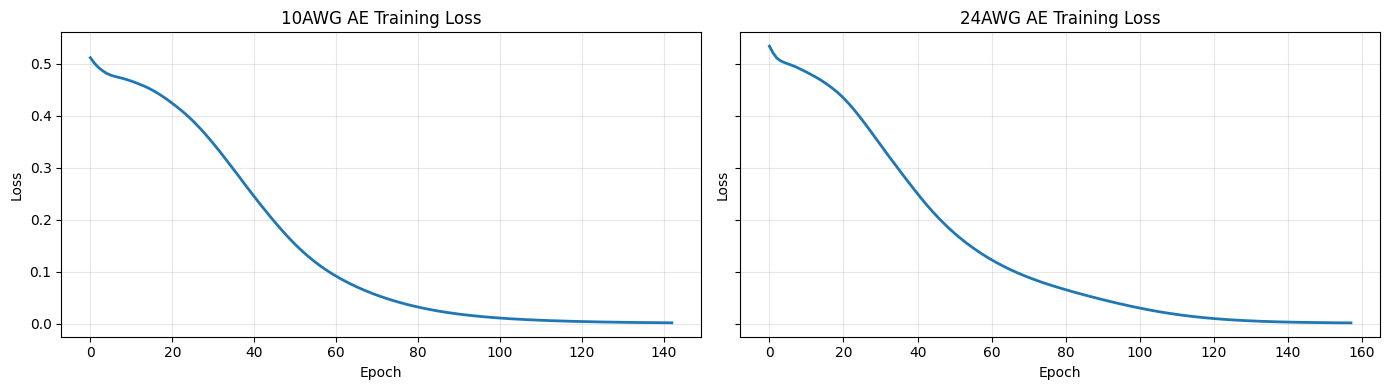

In [ ]:
# 학습 loss 확인
fig, axes = plt.subplots(1, len(models_by_file), figsize=(7 * len(models_by_file), 4), sharey=True)

if len(models_by_file) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_by_file.items()):
    ax.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
    ax.set_title(f"{name} AE Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1-4. Reconstruction Error 계산

In [ ]:
# 전체 포인트 평균 RE를 최종 RE로 사용함
error_tables = {}

for name, df in datasets.items():
    x_all = df[force_cols].apply(pd.to_numeric, errors="coerce")

    x_scaled = scalers[name].transform(x_all)
    x_pred_scaled = models_by_file[name].predict(x_scaled)

    # 포인트별 RE
    point_re = (x_scaled - x_pred_scaled) ** 2

    # 전체 평균 RE
    final_re = point_re.mean(axis=1)

    error_df = pd.DataFrame({
        "sample_index": df.index,
        "reconstruction_error": final_re,
        "Results": df["Results"].values,
    })

    error_tables[name] = error_df

    print(f"[{name}] Reconstruction Error Calculation Complete")
    display(error_df.head())

[10AWG] Reconstruction Error Calculation Complete


,sample_index,reconstruction_error,Results
0,0,0.001851,g
1,1,0.000552,g
2,2,0.001197,g
3,3,0.000067,g
4,4,0.003363,g


[24AWG] Reconstruction Error Calculation Complete


,sample_index,reconstruction_error,Results
0,0,0.000178,g
1,1,0.000166,g
2,2,0.001391,g
3,3,0.000265,g
4,4,0.003144,g


## 1-5. Reconstruction Error Plot

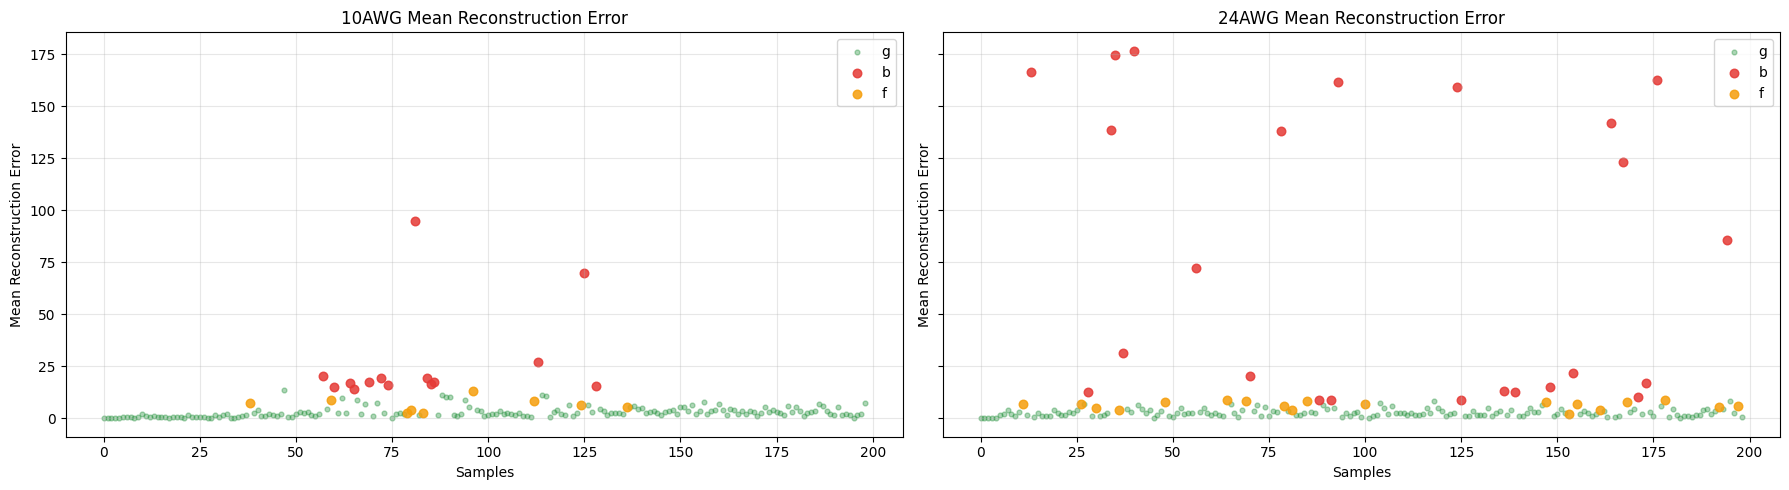

In [ ]:
# g는 초록, b는 빨강, f는 주황으로 표시함
fig, axes = plt.subplots(1, len(error_tables), figsize=(9 * len(error_tables), 5), sharey=True)

if len(error_tables) == 1:
    axes = [axes]

for ax, (name, error_df) in zip(axes, error_tables.items()):
    for label, color in [("g", "#168a2f"), ("b", "#e53935"), ("f", "#f59e0b")]:
        label_df = error_df[error_df["Results"] == label]

        ax.scatter(
            label_df["sample_index"],
            label_df["reconstruction_error"],
            color=color,
            alpha=0.85 if label in ["b", "f"] else 0.35,
            s=38 if label in ["b", "f"] else 12,
            label=label,
        )

    ax.set_title(f"{name} Mean Reconstruction Error")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Mean Reconstruction Error")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 2. Field Data Prototype

20230420, 20230426 실전 데이터를 기존 AE 방식으로 분석함

## 2-1. 데이터 읽기 및 저장

In [ ]:
%reset -f

from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# 학습 파라미터
SEED = 42
LEARNING_RATE = 0.001
EPOCHS = 200
TRAIN_G_COUNT = 5

random.seed(SEED)
np.random.seed(SEED)

# 데이터 경로
DATA_DIR = Path("/content/data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 사용할 CSV 파일
csv_files = {
    "20230420": "20230420.csv",
    "20230426": "20230426.csv",
}

# CSV를 읽어서 저장
datasets = {}
for name, file_name in csv_files.items():
    csv_path = DATA_DIR / file_name
    datasets[name] = pd.read_csv(csv_path)
    print(f"{name}: {datasets[name].shape}")

20230420: (1519, 201)
20230426: (1486, 201)


## 2-2. 첫 5개 g 샘플 선택

In [ ]:
# 첫 5개 g 샘플을 학습 데이터로 사용함
train_data = {}
base_train_indices = {}

for name, df in datasets.items():
    g_df = df[df["Results"] == "g"]
    base_g = g_df.head(TRAIN_G_COUNT)

    train_data[name] = base_g[force_cols].copy()

    print(f"[{name}] 학습 데이터: {train_data[name].shape}")

[20230420] 학습 데이터: (5, 200)
[20230426] 학습 데이터: (5, 200)


## 2-3. AE 모델 학습

In [ ]:
# 200 -> 32 -> 16 -> 32 -> 200 AE 모델 생성함
def build_autoencoder():
    return MLPRegressor(
        hidden_layer_sizes=(32, 16, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=LEARNING_RATE,
        max_iter=EPOCHS,
        random_state=SEED,
        early_stopping=False,
    )

In [ ]:
# 파일별로 첫 5개 g 데이터로 AE 학습함
models_by_file = {}
imputers = {}
scalers = {}

for name, x_train_df in train_data.items():
    x_train = x_train_df.apply(pd.to_numeric, errors="coerce")

    # 학습 정상 데이터 기준으로 표준화함
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)

    model = build_autoencoder()
    model.fit(x_train_scaled, x_train_scaled)

    models_by_file[name] = model
    scalers[name] = scaler

    print(f"[{name}] AE 학습 완료")
    print(f"학습률: {LEARNING_RATE}")
    print(f"Epoch: {EPOCHS}")
    print(f"반복 횟수: {model.n_iter_}")
    print(f"마지막 loss: {model.loss_:.6f}")

[20230420] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 170
마지막 loss: 0.002652
[20230426] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 161
마지막 loss: 0.002205


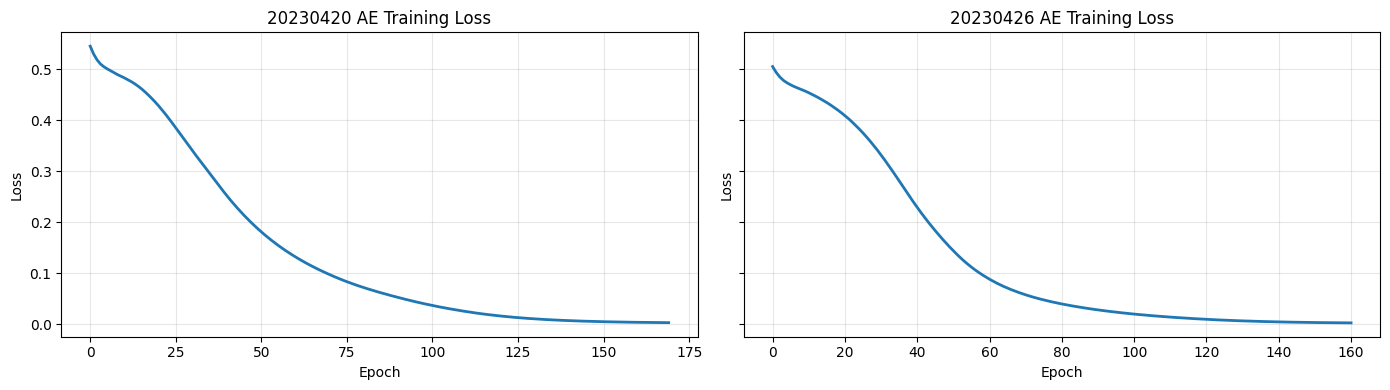

In [ ]:
# 학습 loss 확인함
fig, axes = plt.subplots(1, len(models_by_file), figsize=(7 * len(models_by_file), 4), sharey=True)

if len(models_by_file) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_by_file.items()):
    ax.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
    ax.set_title(f"{name} AE Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2-4. Reconstruction Error 계산

In [ ]:
# 전체 포인트 평균 RE를 최종 RE로 사용함
error_tables = {}

for name, df in datasets.items():
    x_all = df[force_cols].apply(pd.to_numeric, errors="coerce")

    x_scaled = scalers[name].transform(x_all)
    x_pred_scaled = models_by_file[name].predict(x_scaled)

    # 포인트별 RE임
    point_re = (x_scaled - x_pred_scaled) ** 2

    # 전체 평균 RE임
    final_re = point_re.mean(axis=1)

    error_df = pd.DataFrame({
        "sample_index": df.index,
        "reconstruction_error": final_re,
        "Results": df["Results"].values,
    })

    error_tables[name] = error_df

    print(f"[{name}] Reconstruction Error Calculation Complete")
    display(error_df.head())

[20230420] Reconstruction Error Calculation Complete


,sample_index,reconstruction_error,Results
0,0,0.003531,g
1,1,0.000511,g
2,2,0.005655,g
3,3,0.000028,g
4,4,0.000258,g


[20230426] Reconstruction Error Calculation Complete


,sample_index,reconstruction_error,Results
0,0,0.000836,g
1,1,0.000055,g
2,2,0.000076,g
3,3,0.000510,g
4,4,0.005153,g


## 2-5. Reconstruction Error Plot

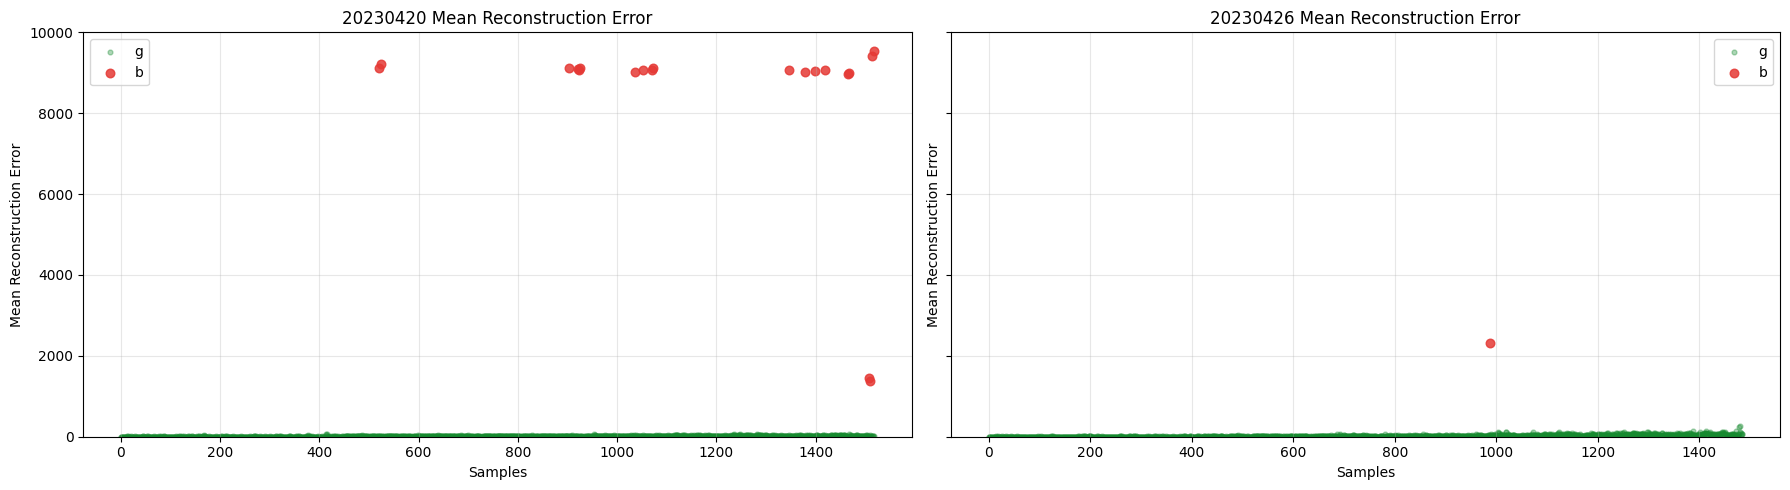

In [ ]:
# g는 초록, b는 빨강으로 표시함
fig, axes = plt.subplots(1, len(error_tables), figsize=(9 * len(error_tables), 5), sharey=True)

if len(error_tables) == 1:
    axes = [axes]

label_styles = {
    "g": {"color": "#168a2f", "alpha": 0.35, "s": 12},
    "b": {"color": "#e53935", "alpha": 0.85, "s": 38},
}

for ax, (name, error_df) in zip(axes, error_tables.items()):
    for label, style in label_styles.items():
        label_df = error_df[error_df["Results"] == label]

        ax.scatter(
            label_df["sample_index"],
            label_df["reconstruction_error"],
            color=style["color"],
            alpha=style["alpha"],
            s=style["s"],
            label=label,
        )

    ax.set_title(f"{name} Mean Reconstruction Error")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Mean Reconstruction Error")
    ax.set_ylim(0, 10000)
    ax.set_yticks(range(0, 10001, 2000))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

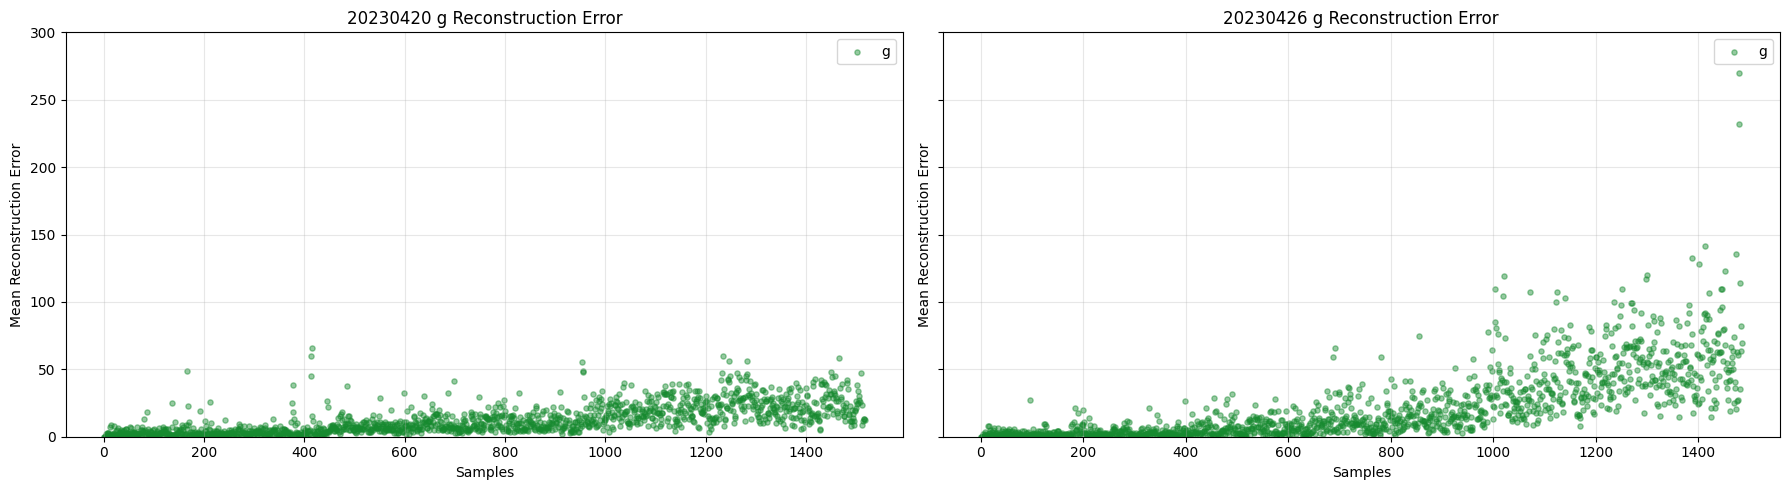

In [ ]:
# g 샘플만 따로 표시함
fig, axes = plt.subplots(1, len(error_tables), figsize=(9 * len(error_tables), 5), sharey=True)

if len(error_tables) == 1:
    axes = [axes]

for ax, (name, error_df) in zip(axes, error_tables.items()):
    g_df = error_df[error_df["Results"] == "g"]

    ax.scatter(
        g_df["sample_index"],
        g_df["reconstruction_error"],
        color="#168a2f",
        alpha=0.45,
        s=14,
        label="g",
    )

    ax.set_title(f"{name} g Reconstruction Error")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Mean Reconstruction Error")
    ax.set_ylim(0, 300)
    ax.set_yticks(range(0, 301, 50))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 3. Drift Prototype

첫 5개 정상(g) 평균을 reference로 두고, EMA 방식으로 공정 drift를 보정함

## 3-1. 데이터 읽기 및 설정

In [ ]:
%reset -f

from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# 학습 파라미터
SEED = 42
LEARNING_RATE = 0.001
EPOCHS = 200
TRAIN_G_COUNT = 5

# DaDrift 관련 파라미터
RE_THRESHOLD = 50
alpha = 0.7

random.seed(SEED)
np.random.seed(SEED)

# 데이터 경로 설정함
DATA_DIR = Path("/content/data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 사용할 CSV 파일 설정함
csv_files = {
    "20230420": "20230420.csv",
    "20230426": "20230426.csv",
}

# CSV를 읽어서 저장함
datasets = {}

for name, file_name in csv_files.items():
    csv_path = DATA_DIR / file_name
    datasets[name] = pd.read_csv(csv_path)
    print(f"{name}: {datasets[name].shape}")

20230420: (1519, 201)
20230426: (1486, 201)


## 3-2. 첫 5개 g 샘플 선택 및 Reference 데이터 생성

In [ ]:
# 첫 5개 g 샘플을 학습 데이터와 reference로 사용함
train_data = {}
reference_data = {}

for name, df in datasets.items():
    g_df = df[df["Results"] == "g"]
    base_g = g_df.head(TRAIN_G_COUNT)

    train_data[name] = base_g[force_cols].copy()
    reference_data[name] = train_data[name].mean(axis=0).to_numpy(dtype="float32")

    print(f"[{name}] 학습 데이터: {train_data[name].shape}")

[20230420] 학습 데이터: (5, 200)
[20230426] 학습 데이터: (5, 200)


## 3-3. AE 모델 학습

In [ ]:
# 200 -> 32 -> 16 -> 32 -> 200 AE 모델 생성함
def build_autoencoder():
    return MLPRegressor(
        hidden_layer_sizes=(32, 16, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=LEARNING_RATE,
        max_iter=EPOCHS,
        random_state=SEED,
        early_stopping=False,
    )

In [ ]:
# 파일별로 첫 5개 g 데이터로 AE 학습함
models_by_file = {}
scalers = {}

for name, x_train_df in train_data.items():
    x_train = x_train_df.apply(pd.to_numeric, errors="coerce")

    # 학습 정상 데이터 기준으로 표준화함
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)

    model = build_autoencoder()
    model.fit(x_train_scaled, x_train_scaled)

    models_by_file[name] = model
    scalers[name] = scaler

    print(f"[{name}] AE 학습 완료")
    print(f"학습률: {LEARNING_RATE}")
    print(f"Epoch: {EPOCHS}")
    print(f"반복 횟수: {model.n_iter_}")
    print(f"마지막 loss: {model.loss_:.6f}")

[20230420] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 170
마지막 loss: 0.002652
[20230426] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 161
마지막 loss: 0.002205


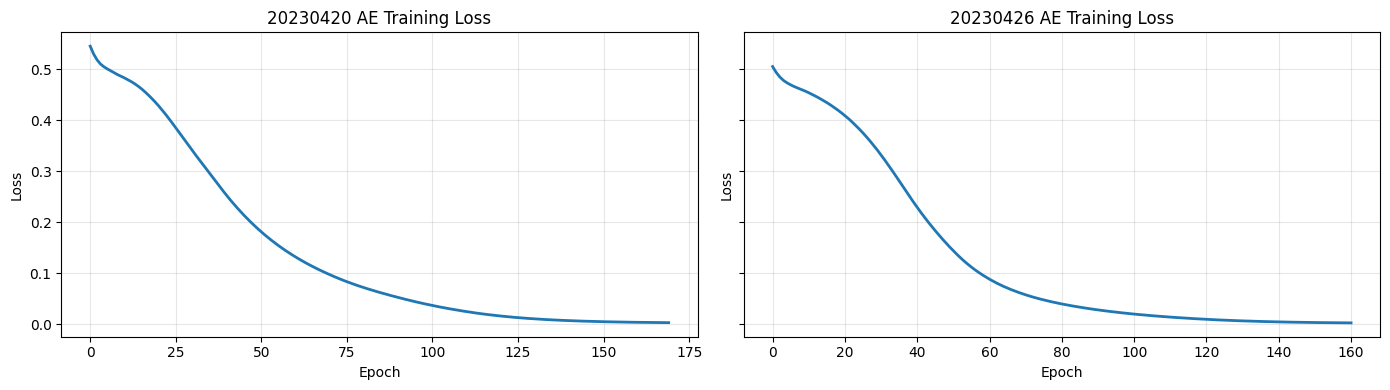

In [ ]:
# 학습 loss 확인함
fig, axes = plt.subplots(1, len(models_by_file), figsize=(7 * len(models_by_file), 4), sharey=True)

if len(models_by_file) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_by_file.items()):
    ax.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
    ax.set_title(f"{name} AE Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3-4. Drift Reconstruction Error 계산

In [ ]:
# 전체 포인트 평균 RE를 최종 RE로 사용함
drift_result_tables = {}

for name, df in datasets.items():
    x_all = df[force_cols].apply(pd.to_numeric, errors="coerce")

    model = models_by_file[name]
    scaler = scalers[name]
    reference = reference_data[name]

    # 처음 drift는 0으로 시작함
    drift = np.zeros(len(force_cols), dtype="float32")
    result_rows = []

    # 학습에 사용한 첫 5개 g 이후부터 테스트함
    for sample_idx in range(TRAIN_G_COUNT, len(x_all)):
        measured = x_all.iloc[sample_idx].to_numpy(dtype="float32")

        # 기존 방식 RE 계산함
        original_scaled = scaler.transform(
            pd.DataFrame([measured], columns=force_cols)
        )
        original_pred_scaled = model.predict(original_scaled)
        original_point_re = (original_scaled - original_pred_scaled) ** 2
        original_re = original_point_re.mean(axis=1)[0]

        # drift를 더해서 보정함
        corrected_measured = measured + drift

        # drift 보정 후 RE 계산함
        corrected_scaled = scaler.transform(
            pd.DataFrame([corrected_measured], columns=force_cols)
        )
        corrected_pred_scaled = model.predict(corrected_scaled)
        corrected_point_re = (corrected_scaled - corrected_pred_scaled) ** 2
        drift_re = corrected_point_re.mean(axis=1)[0]

        # 정상으로 판단되면 drift를 업데이트함 (EMA)
        is_update = drift_re <= RE_THRESHOLD

        if is_update:
            new_drift = reference - measured
            drift = (alpha * drift) + ((1-alpha) * new_drift)

        result_rows.append({
            "sample_index": sample_idx,
            "original_re": original_re,
            "drift_re": drift_re,
            "is_update": is_update,
            "Results": df.iloc[sample_idx]["Results"],
        })

    drift_result_tables[name] = pd.DataFrame(result_rows)

    print(f"[{name}] Drift RE Calculation Complete")
    display(drift_result_tables[name].head())

[20230420] Drift RE Calculation Complete


,sample_index,original_re,drift_re,is_update,Results
0,5,1.778176,1.778176,True,g
1,6,1.470657,1.944625,True,g
2,7,3.105423,2.947938,True,g
3,8,2.433041,2.143061,True,g
4,9,2.805743,1.937149,True,g


[20230426] Drift RE Calculation Complete


,sample_index,original_re,drift_re,is_update,Results
0,5,2.348721,2.348721,True,g
1,6,0.360180,0.374497,True,g
2,7,0.902172,0.789421,True,g
3,8,1.719622,1.023115,True,g
4,9,3.513985,2.826313,True,g


## 3-5. Drift RE Plot

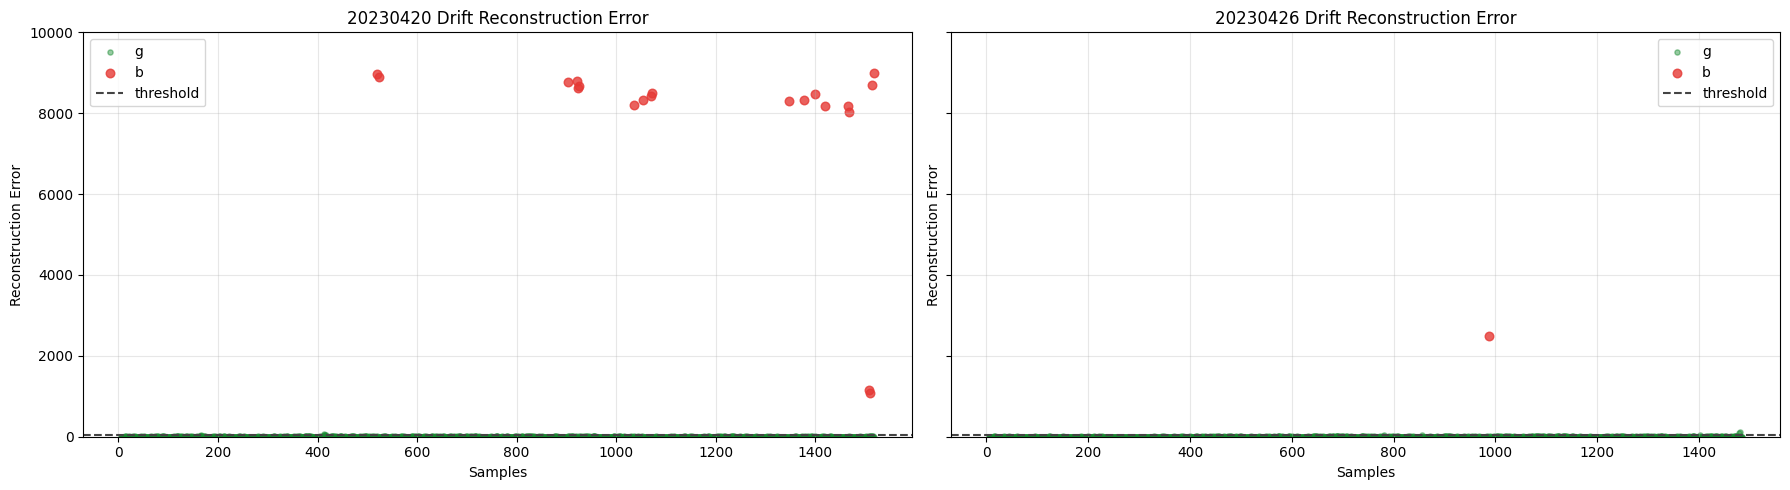

In [ ]:
# drift 보정 RE를 표시함
fig, axes = plt.subplots(1, len(drift_result_tables), figsize=(9 * len(drift_result_tables), 5), sharey=True)

if len(drift_result_tables) == 1:
    axes = [axes]

for ax, (name, result_df) in zip(axes, drift_result_tables.items()):
    for label, color in [("g", "#168a2f"), ("b", "#e53935")]:
        label_df = result_df[result_df["Results"] == label]

        ax.scatter(
            label_df["sample_index"],
            label_df["drift_re"],
            color=color,
            alpha=0.8 if label == "b" else 0.45,
            s=38 if label == "b" else 14,
            label=label,
        )

    ax.axhline(RE_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5, label="threshold")
    ax.set_title(f"{name} Drift Reconstruction Error")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Reconstruction Error")
    ax.set_ylim(0, 10000)
    ax.set_yticks(range(0, 10001, 2000))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

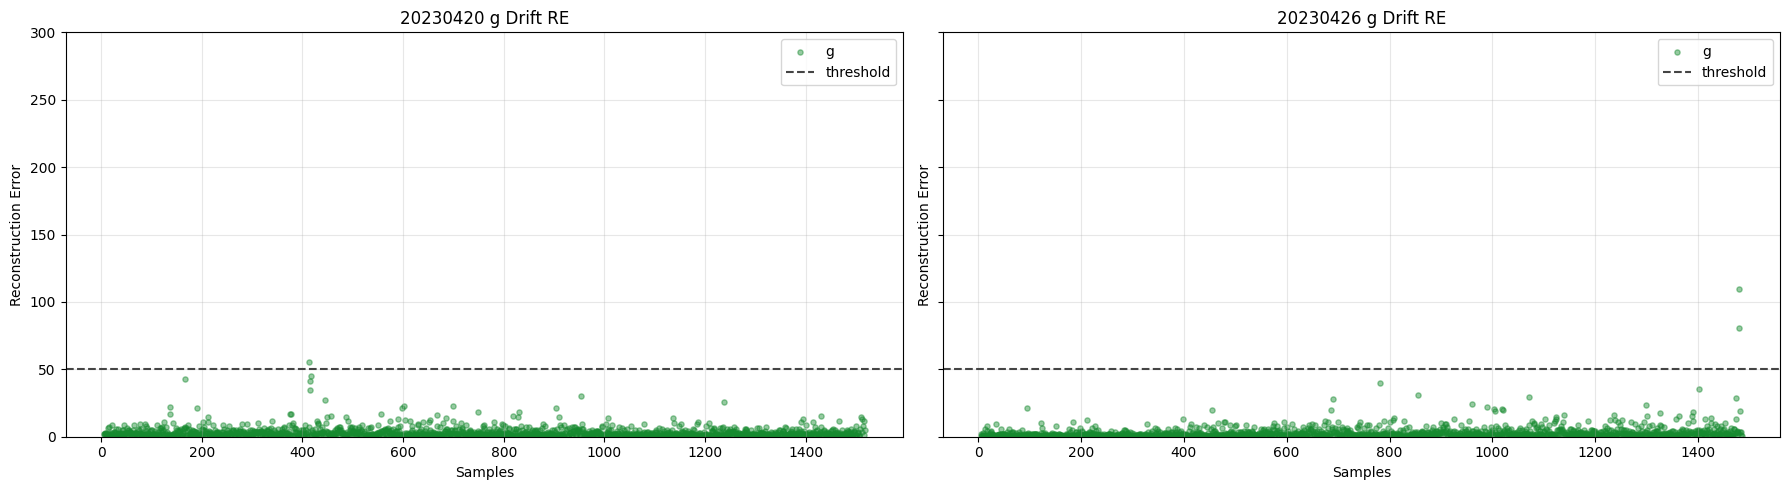

In [ ]:
# g 샘플의 drift 보정 RE만 표시함
fig, axes = plt.subplots(1, len(drift_result_tables), figsize=(9 * len(drift_result_tables), 5), sharey=True)

if len(drift_result_tables) == 1:
    axes = [axes]

for ax, (name, result_df) in zip(axes, drift_result_tables.items()):
    g_df = result_df[result_df["Results"] == "g"]

    ax.scatter(
        g_df["sample_index"],
        g_df["drift_re"],
        color="#168a2f",
        alpha=0.45,
        s=14,
        label="g",
    )

    ax.axhline(RE_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5, label="threshold")
    ax.set_title(f"{name} g Drift RE")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Reconstruction Error")
    ax.set_ylim(0, 300)
    ax.set_yticks(range(0, 301, 50))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()